In [1]:
!pip install -q "transformers>=4.46,<5" "datasets>=3,<4" "accelerate>=1,<2" evaluate scikit-learn pyarrow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 46.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [43]:
import warnings
import torch
import transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments
)
import datasets
from datasets import Dataset
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from pathlib import Path
from safetensors.torch import load_file
from google.colab import files
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

warnings.filterwarnings("ignore")


In [3]:

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("Datasets version:", datasets.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "GPU is not available. Select Runtime → Change runtime type → T4 GPU."
    )

PyTorch version: 2.11.0+cu128
Transformers version: 5.13.1
Datasets version: 4.0.0
CUDA available: True
GPU: Tesla T4


In [4]:
# upload data
uploaded = files.upload()
data_filename = next(iter(uploaded))

print("Uploaded file:", data_filename)

Saving llm_hallucination_benchmark_v2_research_grade (1).csv to llm_hallucination_benchmark_v2_research_grade (1).csv
Uploaded file: llm_hallucination_benchmark_v2_research_grade (1).csv


In [5]:
# df

raw_df = pd.read_csv(data_filename)

print("Dataset shape:", raw_df.shape)
print("\nColumns:")
print(raw_df.columns.tolist())

required_columns = [
    "prompt_id",
    "prompt_text",
    "ground_truth",
    "gpt4o_response",
    "gpt4o_hallucinated",
    "claude_response",
    "claude_hallucinated",
    "gemini_response",
    "gemini_hallucinated",
    "llama3_response",
    "llama3_hallucinated",
    "mistral_response",
    "mistral_hallucinated",
    "gemma_response",
    "gemma_hallucinated",
]

missing_columns = [
    column for column in required_columns
    if column not in raw_df.columns
]

print("\nMissing required columns:", missing_columns)

Dataset shape: (25200, 24)

Columns:
['prompt_id', 'prompt_text', 'prompt_source', 'topic_category', 'difficulty', 'gpt4o_response', 'claude_response', 'gemini_response', 'llama3_response', 'mistral_response', 'gemma_response', 'ground_truth', 'ground_truth_source', 'gpt4o_hallucinated', 'claude_hallucinated', 'gemini_hallucinated', 'llama3_hallucinated', 'mistral_hallucinated', 'gemma_hallucinated', 'n_models_hallucinated', 'hallucination_type', 'hallucinated_span', 'severity', 'annotation_confidence']

Missing required columns: []


In [6]:
# mapping
model_map = {
    "gpt4o": ("gpt4o_response", "gpt4o_hallucinated"),
    "claude": ("claude_response", "claude_hallucinated"),
    "gemini": ("gemini_response", "gemini_hallucinated"),
    "llama3": ("llama3_response", "llama3_hallucinated"),
    "mistral": ("mistral_response", "mistral_hallucinated"),
    "gemma": ("gemma_response", "gemma_hallucinated"),
}

long_parts = []

for model_name, (response_column, label_column) in model_map.items():
    part = raw_df[
        [
            "prompt_id",
            "prompt_text",
            "ground_truth",
            response_column,
            label_column,
        ]
    ].copy()

    part = part.rename(
        columns={
            response_column: "response",
            label_column: "labels",
        }
    )

    part["model_name"] = model_name
    long_parts.append(part)

df_long = pd.concat(long_parts, ignore_index=True)

print("Long dataset shape:", df_long.shape)
df_long.head()

Long dataset shape: (151200, 6)


,prompt_id,prompt_text,ground_truth,response,labels,model_name
0,TEC_000001,What does GPU stand for?,Graphics Processing Unit,Based on verified information: Graphics Proces...,0,gpt4o
1,TEC_000002,What does API stand for?,Application Programming Interface,Based on verified information: Application Pro...,0,gpt4o
2,TEC_000003,What programming language was Python named after?,Monty Python's Flying Circus (the TV show),Based on verified information: Monty Python's ...,0,gpt4o
3,TEC_000004,Who co-founded Apple Inc.?,"Steve Jobs, Steve Wozniak, and Ronald Wayne","Based on verified information: Steve Jobs, Ste...",0,gpt4o
4,TEC_000005,What does HTML stand for?,HyperText Markup Language,Based on verified information: HyperText Marku...,0,gpt4o


In [7]:
# clean up and format code
df_long = df_long.dropna(
    subset=["prompt_text", "ground_truth", "response", "labels"]
).copy()

df_long["prompt_text"] = df_long["prompt_text"].astype(str).str.strip()
df_long["ground_truth"] = df_long["ground_truth"].astype(str).str.strip()
df_long["response"] = df_long["response"].astype(str).str.strip()
df_long["labels"] = df_long["labels"].astype(int)

# Remove the dataset-specific prefix that reveals the target.
df_long["response"] = df_long["response"].str.removeprefix(
    "Based on verified information: "
)

# Sequence 1: question plus trusted evidence.
df_long["question_evidence"] = (
    "Question: "
    + df_long["prompt_text"]
    + " Reference evidence: "
    + df_long["ground_truth"]
)

print("Clean dataset shape:", df_long.shape)
print("Unique prompts:", df_long["prompt_id"].nunique())

print("\nClass counts:")
print(df_long["labels"].value_counts().sort_index())

print("\nClass proportions:")
print(df_long["labels"].value_counts(normalize=True).sort_index())

df_long[
    [
        "question_evidence",
        "response",
        "labels",
        "model_name",
    ]
].sample(3, random_state=42)


Clean dataset shape: (151200, 7)
Unique prompts: 25200

Class counts:
labels
0    118448
1     32752
Name: count, dtype: int64

Class proportions:
labels
0    0.783386
1    0.216614
Name: proportion, dtype: float64


,question_evidence,response,labels,model_name
90870,Question: What is the vanishing gradient probl...,As gradients are backpropagated through many l...,0,llama3
118547,Question: What is the difference between innat...,Innate immunity is nonspecific and immediate; ...,0,mistral
43005,Question: Who proposed the theory of evolution...,Charles Darwin,0,claude


In [9]:
# first split: 85% train+validation, 15% final test.
test_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42,
)

train_val_idx, test_idx = next(
    test_splitter.split(
        df_long,
        y=df_long["labels"],
        groups=df_long["prompt_id"],
    )
)

train_val_df = df_long.iloc[train_val_idx].copy()
test_df = df_long.iloc[test_idx].copy()

# Second split: 70% train, 15% validation.
validation_fraction = 0.15 / 0.85

validation_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=validation_fraction,
    random_state=42,
)

train_idx, validation_idx = next(
    validation_splitter.split(
        train_val_df,
        y=train_val_df["labels"],
        groups=train_val_df["prompt_id"],
    )
)

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
validation_df = train_val_df.iloc[validation_idx].reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Train shape: (105834, 7)
Validation shape: (22686, 7)
Test shape: (22680, 7)


In [10]:
# data leakage and class distribution analysis
train_prompts = set(train_df["prompt_id"])
validation_prompts = set(validation_df["prompt_id"])
test_prompts = set(test_df["prompt_id"])

print(
    "Train/validation prompt overlap:",
    len(train_prompts & validation_prompts),
)
print(
    "Train/test prompt overlap:",
    len(train_prompts & test_prompts),
)
print(
    "Validation/test prompt overlap:",
    len(validation_prompts & test_prompts),
)

for name, frame in [
    ("Train", train_df),
    ("Validation", validation_df),
    ("Test", test_df),
]:
    print(f"\n{name}")
    print("Rows:", len(frame))
    print("Unique prompts:", frame["prompt_id"].nunique())
    print(
        frame["labels"]
        .value_counts(normalize=True)
        .sort_index()
        .round(4)
    )

Train/validation prompt overlap: 0
Train/test prompt overlap: 0
Validation/test prompt overlap: 0

Train
Rows: 105834
Unique prompts: 17639
labels
0    0.7841
1    0.2159
Name: proportion, dtype: float64

Validation
Rows: 22686
Unique prompts: 3781
labels
0    0.7814
1    0.2186
Name: proportion, dtype: float64

Test
Rows: 22680
Unique prompts: 3780
labels
0    0.7818
1    0.2182
Name: proportion, dtype: float64


In [13]:
# token lenth analysis
model_name = "google-bert/bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

length_sample = train_df.sample(
    n=5000,
    random_state=42,
)

encoded_sample = tokenizer(
    length_sample["question_evidence"].tolist(),
    length_sample["response"].tolist(),
    truncation=False,
    padding=False,
)

token_lengths = np.array(
    [len(input_ids) for input_ids in encoded_sample["input_ids"]]
)

print("Token length percentiles:")
for percentile in [50, 75, 90, 95, 99, 100]:
    value = np.percentile(token_lengths, percentile)
    print(f"{percentile:>3}%: {value:.0f}")

print("\nSequences longer than 256:", (token_lengths > 256).mean())
print("Sequences longer than 384:", (token_lengths > 384).mean())
print("Sequences longer than 512:", (token_lengths > 512).mean())

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Token length percentiles:
 50%: 55
 75%: 69
 90%: 79
 95%: 90
 99%: 108
100%: 118

Sequences longer than 256: 0.0
Sequences longer than 384: 0.0
Sequences longer than 512: 0.0


In [19]:
# class weight
classes = np.array([0, 1])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["labels"],
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float32,
)

print("Class 0 weight:", class_weights[0].item())
print("Class 1 weight:", class_weights[1].item())

Class 0 weight: 0.6376387476921082
Class 1 weight: 2.3163492679595947


In [ ]:


dataset_columns = [
    "question_evidence",
    "response",
    "labels",
]

train_dataset = Dataset.from_pandas(
    train_df[dataset_columns],
    preserve_index=False,
)

validation_dataset = Dataset.from_pandas(
    validation_df[dataset_columns],
    preserve_index=False,
)

test_dataset = Dataset.from_pandas(
    test_df[dataset_columns],
    preserve_index=False,
)

print(train_dataset)
print(validation_dataset)
print(test_dataset)

In [21]:
# transform into Hugging Face Dataset
dataset_columns = [
    "question_evidence",
    "response",
    "labels",
]

train_dataset = Dataset.from_pandas(
    train_df[dataset_columns],
    preserve_index=False,
)

validation_dataset = Dataset.from_pandas(
    validation_df[dataset_columns],
    preserve_index=False,
)

test_dataset = Dataset.from_pandas(
    test_df[dataset_columns],
    preserve_index=False,
)

print(train_dataset)
print(validation_dataset)
print(test_dataset)

Dataset({
    features: ['question_evidence', 'response', 'labels'],
    num_rows: 105834
})
Dataset({
    features: ['question_evidence', 'response', 'labels'],
    num_rows: 22686
})
Dataset({
    features: ['question_evidence', 'response', 'labels'],
    num_rows: 22680
})


In [22]:
# tokenization
max_length = 160

def tokenize_batch(batch):
    return tokenizer(
        batch["question_evidence"],
        batch["response"],
        truncation=True,
        max_length=max_length,
    )

train_tokenized = train_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["question_evidence", "response"],
)

validation_tokenized = validation_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["question_evidence", "response"],
)

test_tokenized = test_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=["question_evidence", "response"],
)

print(train_tokenized)
print(validation_tokenized)
print(test_tokenized)

Map:   0%|          | 0/105834 [00:00<?, ? examples/s]

Map:   0%|          | 0/22686 [00:00<?, ? examples/s]

Map:   0%|          | 0/22680 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 105834
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 22686
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 22680
})


In [24]:
# model and dynamic padding
print("Class weights:", class_weights)

id2label = {
    0: "Non-Hallucination",
    1: "Hallucination",
}

label2id = {
    "Non-Hallucination": 0,
    "Hallucination": 1,
}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
)

print("Model:", model.config.name_or_path)
print("Number of labels:", model.config.num_labels)

Class weights: tensor([0.6376, 2.3163])


model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: google-bert/bert-base-uncased
Number of labels: 2


In [26]:
# metrics
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=1,
    ).numpy()[:, 1]

    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            labels,
            probabilities,
        ),
        "pr_auc": average_precision_score(
            labels,
            probabilities,
        ),
    }

In [28]:
# trainer with weighted loss
class WeightedTrainer(Trainer):
    def __init__(
        self,
        *args,
        class_weights=None,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)

        if class_weights is None:
            raise ValueError("class_weights must be provided.")

        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_function = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )

        loss = loss_function(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
        )

        if return_outputs:
            return loss, outputs

        return loss

In [30]:
# training arguments, training parameters
training_args = TrainingArguments(
    output_dir="/content/evidence_aware_bert_checkpoints",

    learning_rate=2e-5,
    num_train_epochs=2,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,

    weight_decay=0.01,
    warmup_ratio=0.1,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=250,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,

    fp16=True,

    seed=42,
    data_seed=42,

    report_to="none",
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [31]:
# create trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=validation_tokenized,

    data_collator=data_collator,
    processing_class=tokenizer,

    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Train examples:", len(trainer.train_dataset))
print("Validation examples:", len(trainer.eval_dataset))
print("Total parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")
print("FP16 enabled:", trainer.args.fp16)
print("Epochs:", trainer.args.num_train_epochs)

Train examples: 105834
Validation examples: 22686
Total parameters: 109,483,778
Trainable parameters: 109,483,778
FP16 enabled: True
Epochs: 2


In [32]:
# train the Bert model
torch.cuda.empty_cache()

training_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Pr Auc
1,0.000004,0.000002,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc,Pr Auc
1,0.000004,0.000002,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,0.000001,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

In [34]:
# correct checkpoint upload
best_checkpoint = Path(trainer.state.best_model_checkpoint)
checkpoint_file = best_checkpoint / "model.safetensors"

print("Best checkpoint:", best_checkpoint)
print("Checkpoint file exists:", checkpoint_file.exists())

saved_state_dict = load_file(checkpoint_file)

fixed_state_dict = {}

for key, value in saved_state_dict.items():
    fixed_key = (
        key
        .replace("LayerNorm.gamma", "LayerNorm.weight")
        .replace("LayerNorm.beta", "LayerNorm.bias")
    )
    fixed_state_dict[fixed_key] = value

fixed_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

loading_result = fixed_model.load_state_dict(
    fixed_state_dict,
    strict=False,
)

print("\nMissing keys after correction:")
print(loading_result.missing_keys)

print("\nUnexpected keys after correction:")
print(loading_result.unexpected_keys)

trainer.model = fixed_model.to(trainer.args.device)
model = trainer.model

Best checkpoint: /content/evidence_aware_bert_checkpoints/checkpoint-6615
Checkpoint file exists: True


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Missing keys after correction:
[]

Unexpected keys after correction:
[]


In [35]:
# test set prediction
test_output = trainer.predict(
    test_tokenized,
    metric_key_prefix="test",
)

print("Test metrics:")
for metric_name, metric_value in test_output.metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.6f}")
    else:
        print(f"{metric_name}: {metric_value}")

Test metrics:
test_loss: 0.000002
test_accuracy: 1.000000
test_precision: 1.000000
test_recall: 1.000000
test_f1: 1.000000
test_roc_auc: 1.000000
test_pr_auc: 1.000000
test_runtime: 159.430700
test_samples_per_second: 142.256000
test_steps_per_second: 4.447000


In [37]:
# upload "counterfactual" file
counterfactual_upload = files.upload()
counterfactual_filename = next(iter(counterfactual_upload))

print("Uploaded:", counterfactual_filename)

Saving counterfactual_test (1).csv to counterfactual_test (1).csv
Uploaded: counterfactual_test (1).csv


In [39]:
# prepare external test
counterfactual_df = pd.read_csv(counterfactual_filename)

counterfactual_df["question_evidence"] = (
    "Question: "
    + counterfactual_df["question"].astype(str)
    + " Reference evidence: "
    + counterfactual_df["reference_evidence"].astype(str)
)

counterfactual_df["labels"] = (
    counterfactual_df["expected_label"].astype(int)
)

counterfactual_dataset = Dataset.from_pandas(
    counterfactual_df[
        [
            "question_evidence",
            "answer",
            "labels",
        ]
    ].rename(columns={"answer": "response"}),
    preserve_index=False,
)

counterfactual_tokenized = counterfactual_dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=[
        "question_evidence",
        "response",
    ],
)

print(counterfactual_tokenized)

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 40
})


In [42]:
# external test
counterfactual_output = trainer.predict(
    counterfactual_tokenized,
    metric_key_prefix="counterfactual",
)

counterfactual_logits = counterfactual_output.predictions
counterfactual_predictions = np.argmax(
    counterfactual_logits,
    axis=1,
)

counterfactual_probabilities = torch.softmax(
    torch.tensor(counterfactual_logits),
    dim=1,
).numpy()[:, 1]

counterfactual_results = counterfactual_df.copy()
counterfactual_results["predicted_label"] = (
    counterfactual_predictions
)
counterfactual_results["hallucination_probability"] = (
    counterfactual_probabilities
)
counterfactual_results["is_correct"] = (
    counterfactual_results["expected_label"]
    == counterfactual_results["predicted_label"]
)

print("Counterfactual metrics:")
for metric_name, metric_value in counterfactual_output.metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.6f}")
    else:
        print(f"{metric_name}: {metric_value}")

print("\nClassification report:")
print(
    classification_report(
        counterfactual_results["expected_label"],
        counterfactual_results["predicted_label"],
        target_names=[
            "Non-Hallucination",
            "Hallucination",
        ],
        digits=4,
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        counterfactual_results["expected_label"],
        counterfactual_results["predicted_label"],
    )
)

print("\nAccuracy by answer style:")
print(
    counterfactual_results
    .groupby("answer_style")["is_correct"]
    .mean()
)

print("\nPredicted hallucination rate by answer style:")
print(
    counterfactual_results
    .groupby("answer_style")["predicted_label"]
    .mean()
)

Counterfactual metrics:
counterfactual_loss: 5.528520
counterfactual_accuracy: 0.500000
counterfactual_precision: 0.500000
counterfactual_recall: 0.150000
counterfactual_f1: 0.230769
counterfactual_roc_auc: 0.637500
counterfactual_pr_auc: 0.658623
counterfactual_runtime: 0.214400
counterfactual_samples_per_second: 186.566000
counterfactual_steps_per_second: 9.328000

Classification report:
                   precision    recall  f1-score   support

Non-Hallucination     0.5000    0.8500    0.6296        20
    Hallucination     0.5000    0.1500    0.2308        20

         accuracy                         0.5000        40
        macro avg     0.5000    0.5000    0.4302        40
     weighted avg     0.5000    0.5000    0.4302        40

Confusion matrix:
[[17  3]
 [17  3]]

Accuracy by answer style:
answer_style
long     0.5
short    0.5
Name: is_correct, dtype: float64

Predicted hallucination rate by answer style:
answer_style
long     0.1
short    0.2
Name: predicted_label, dtype


The model is evaluated on a small external counterfactual dataset containing
more subtle factual errors and examples from subject areas that may differ
from the training data. Therefore, this evaluation is treated as an
out-of-distribution diagnostic stress test rather than a final estimate of
model performance.

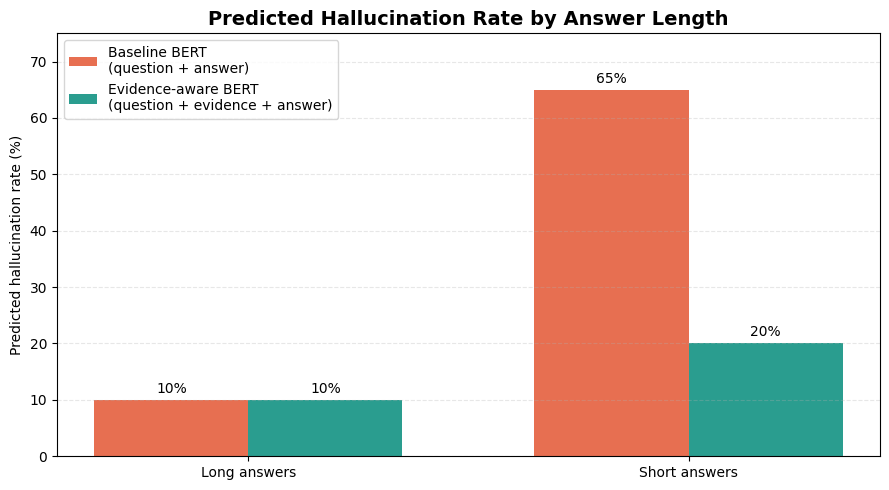

In [45]:
# answer-length bias analysis
answer_styles = ["Long answers", "Short answers"]

baseline_rates = [10, 65]
evidence_aware_rates = [10, 20]

x = np.arange(len(answer_styles))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_baseline = ax.bar(
    x - width / 2,
    baseline_rates,
    width,
    label="Baseline BERT\n(question + answer)",
    color="#E76F51",
)

bars_evidence = ax.bar(
    x + width / 2,
    evidence_aware_rates,
    width,
    label="Evidence-aware BERT\n(question + evidence + answer)",
    color="#2A9D8F",
)

ax.set_title(
    "Predicted Hallucination Rate by Answer Length",
    fontsize=14,
    fontweight="bold",
)

ax.set_ylabel("Predicted hallucination rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(answer_styles)
ax.set_ylim(0, 75)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.bar_label(bars_baseline, fmt="%.0f%%", padding=3)
ax.bar_label(bars_evidence, fmt="%.0f%%", padding=3)

plt.tight_layout()
plt.savefig(
    "/content/answer_length_bias_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

**The baseline BERT model showed a strong dependence on answer length:
it predicted hallucination for 65% of short answers but only 10% of
long answers.

After adding reference evidence to the input, the difference decreased
substantially: the predicted hallucination rates were 20% for short
answers and 10% for long answers.

Therefore, the evidence-aware model reduced the answer-length shortcut.
However, its counterfactual accuracy remained at 50%, and hallucination
recall was only 15%. This indicates that reducing the length bias did not
yet lead to reliable detection of factual contradictions.**

In [46]:
counterfactual_results.to_csv(
    "/content/evidence_aware_counterfactual_results.csv",
    index=False
)

files.download("/content/evidence_aware_counterfactual_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>